# f6_m04b_calibracion.ipynb

## Qué hace
Evalúa la calibración de probabilidades del modelo CatBoost.
Un modelo bien calibrado es aquel donde una probabilidad predicha de 0.7
significa que el 70% de esos alumnos realmente abandona.
Genera reliability diagram, calcula Brier Score y compara calibración
isotónica vs Platt scaling como técnicas de corrección.

## Requisitos
- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/X_train_prep.parquet`
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/y_train.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`

## Genera
- `results/fase6/calibracion_reliability.png`
- `results/fase6/calibracion_distribucion.png`
- `results/fase6/calibracion_metricas.parquet`
- `docs/html/fase6/m04b_calibracion.html`

## Flujo
Cargar datos → reliability diagram → Brier Score →
calibración isotónica y Platt → comparativa → HTML

## Siguiente
`f6_m04c_sostenibilidad.ipynb` — huella de carbono y consumo de memoria

In [1]:
# 1. CONFIGURACIÓN DE RUTAS
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA    = ROOT / 'data' / '05_modelado'
DIR_MODELS  = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS = ROOT / 'results' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_HTML = ROOT / 'docs' / 'html' / 'fase6'
DIR_HTML.mkdir(parents=True, exist_ok=True)

print(f'ROOT:        {ROOT}')
print(f'DIR_RESULTS: {DIR_RESULTS}')

ROOT:        C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# 2. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, f1_score
from src.html.render import render_pagina_desde_fichero

plt.rcParams['figure.dpi'] = 120

print('Imports OK.')
from src.config_entorno import NOMBRES_LEGIBLES_FEATURES


Imports OK.


In [3]:
# 3. CARGAR DATOS Y MODELO
# Necesitamos train para ajustar los calibradores (isotónico y Platt).
# Los calibradores se ajustan sobre train y se evalúan sobre test.

X_test_prep  = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
X_train_prep = pd.read_parquet(DIR_DATA / 'X_train_prep.parquet')
y_test       = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()
y_train      = pd.read_parquet(DIR_DATA / 'y_train.parquet').squeeze()
pipeline_cat = joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl')

y_true  = y_test.values.ravel()
y_train_arr = y_train.values.ravel()

# Probabilidades del modelo original
y_prob = pipeline_cat.predict_proba(X_test_prep)[:, 1]
brier  = brier_score_loss(y_true, y_prob)

print(f'X_test_prep:  {X_test_prep.shape}')
print(f'X_train_prep: {X_train_prep.shape}')
print(f'Brier Score (sin calibrar): {brier:.4f}  (ideal=0, peor=1)')

X_test_prep:  (6725, 27)
X_train_prep: (26896, 27)
Brier Score (sin calibrar): 0.0821  (ideal=0, peor=1)


In [4]:
# 4. CALIBRACIÓN ISOTÓNICA Y PLATT SCALING
# En versiones recientes de sklearn, cv='prefit' fue eliminado.
# Alternativa: usar predict_proba directamente sobre train para ajustar calibradores.

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

# Probabilidades sobre train para ajustar calibradores
y_prob_train = pipeline_cat.predict_proba(X_train_prep)[:, 1]

# Calibración isotónica
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(y_prob_train, y_train_arr)
y_prob_iso  = iso.predict(y_prob)
brier_iso   = brier_score_loss(y_true, y_prob_iso)

# Calibración Platt (regresión logística sobre las probabilidades)
platt = LogisticRegression()
platt.fit(y_prob_train.reshape(-1, 1), y_train_arr)
y_prob_platt = platt.predict_proba(y_prob.reshape(-1, 1))[:, 1]
brier_platt  = brier_score_loss(y_true, y_prob_platt)

print(f'Brier Score original:  {brier:.4f}')
print(f'Brier Score isotónico: {brier_iso:.4f}')
print(f'Brier Score Platt:     {brier_platt:.4f}')

df_cal = pd.DataFrame([
    {'metodo': 'Original',  'brier': brier},
    {'metodo': 'Isotónico', 'brier': brier_iso},
    {'metodo': 'Platt',     'brier': brier_platt},
])
df_cal.to_parquet(DIR_RESULTS / 'calibracion_metricas.parquet')
print('Métricas guardadas.')

Brier Score original:  0.0821
Brier Score isotónico: 0.0733
Brier Score Platt:     0.0753
Métricas guardadas.


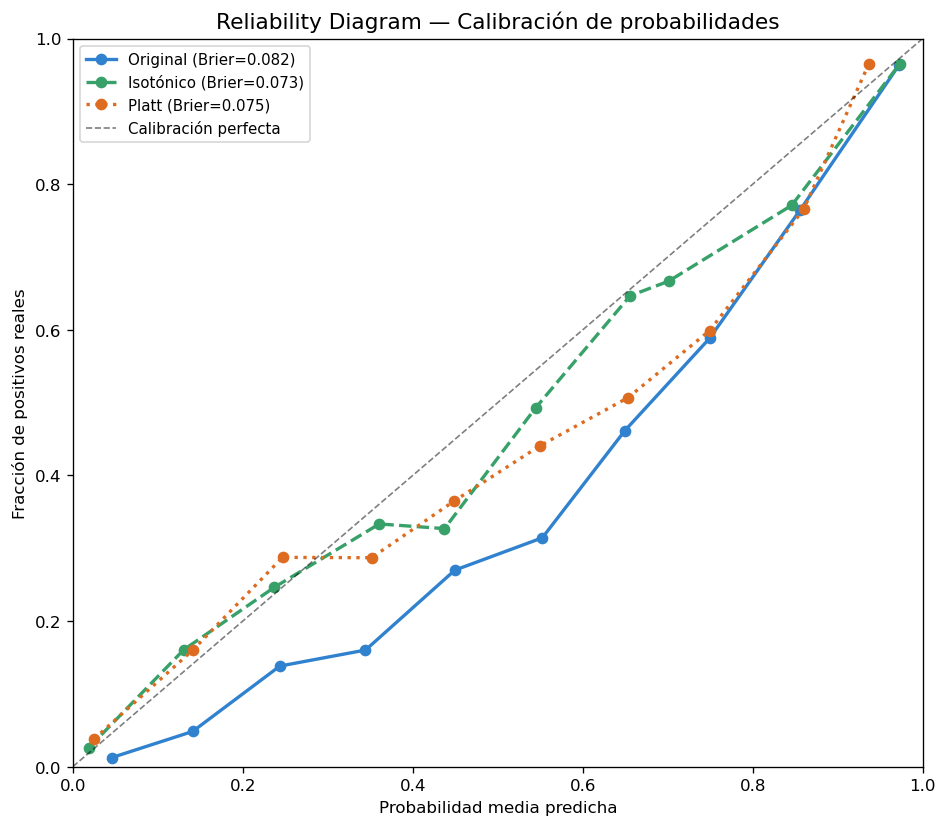

Reliability diagram guardado.


In [5]:
# 5. GRÁFICO 1 — RELIABILITY DIAGRAM (DIAGRAMA DE FIABILIDAD)
# Compara la probabilidad media predicha en cada bin con la frecuencia
# real de abandono en ese bin.
# Diagonal perfecta = calibración perfecta.
# Por encima de la diagonal = modelo subestima el riesgo.
# Por debajo = modelo sobreestima el riesgo.

fig, ax = plt.subplots(figsize=(8, 7))

for y_prob_plot, label, color, ls in [
    (y_prob,       f'Original (Brier={brier:.3f})',      '#3182ce', '-'),
    (y_prob_iso,   f'Isotónico (Brier={brier_iso:.3f})', '#38a169', '--'),
    (y_prob_platt, f'Platt (Brier={brier_platt:.3f})',   '#dd6b20', ':'),
]:
    frac_pos, mean_pred = calibration_curve(y_true, y_prob_plot, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=label, color=color, linestyle=ls, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Calibración perfecta')
ax.set_xlabel('Probabilidad media predicha')
ax.set_ylabel('Fracción de positivos reales')
ax.set_title('Reliability Diagram — Calibración de probabilidades', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
ruta_reliability = DIR_RESULTS / 'calibracion_reliability.png'
plt.savefig(ruta_reliability, dpi=120, bbox_inches='tight')
plt.show()
print('Reliability diagram guardado.')

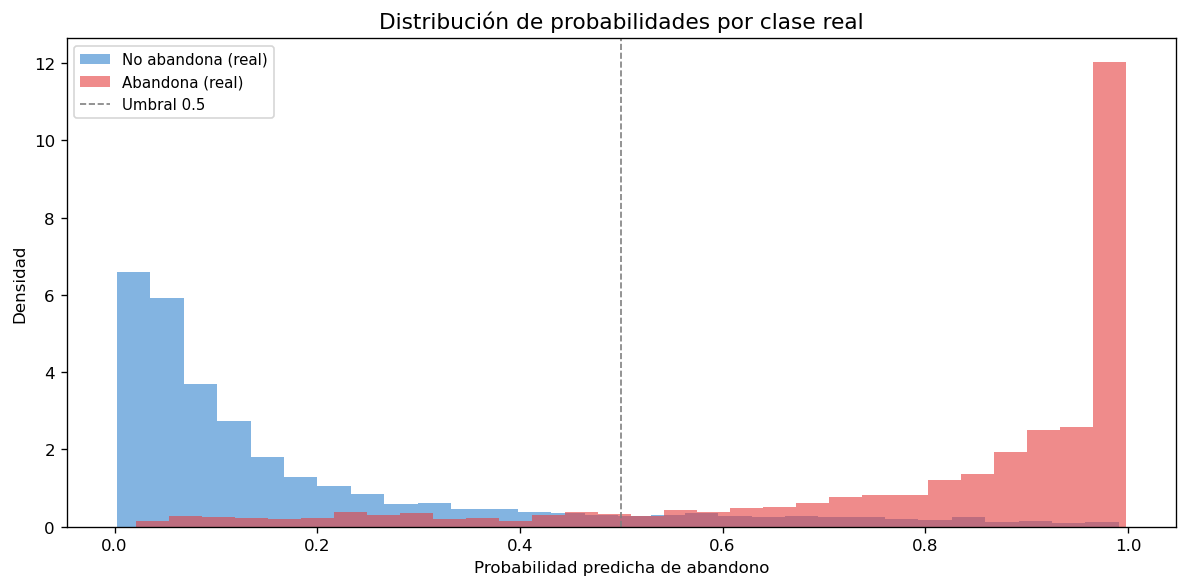

Distribución guardada.


In [6]:
# 6. GRÁFICO 2 — DISTRIBUCIÓN DE PROBABILIDADES
# Histograma de probabilidades predichas para abandonos reales vs no abandonos.
# Una buena separación indica que el modelo discrimina bien.

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_prob[y_true == 0], bins=30, alpha=0.6, color='#3182ce',
        label='No abandona (real)', density=True)
ax.hist(y_prob[y_true == 1], bins=30, alpha=0.6, color='#e53e3e',
        label='Abandona (real)', density=True)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Umbral 0.5')
ax.set_xlabel('Probabilidad predicha de abandono')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades por clase real', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
ruta_dist = DIR_RESULTS / 'calibracion_distribucion.png'
plt.savefig(ruta_dist, dpi=120, bbox_inches='tight')
plt.show()
print('Distribución guardada.')

Umbral 0.50 → F1: 0.8188
Umbral óptimo 0.62 → F1: 0.8288
Mejora F1: +0.0100 (1.2%)


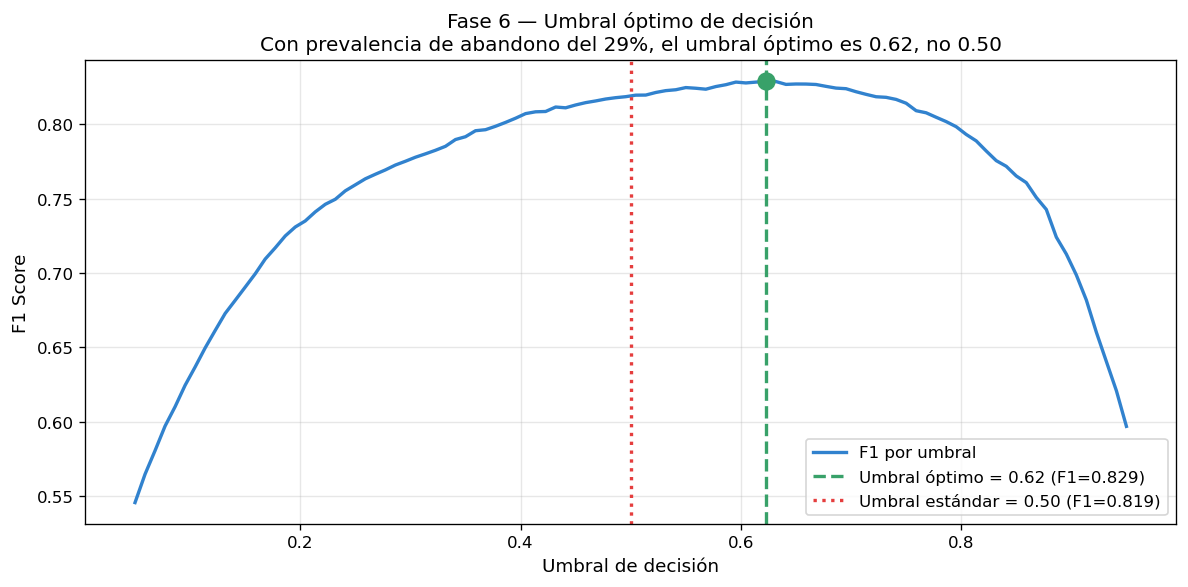

✅ Umbral óptimo guardado: calibracion_umbral_optimo.png


In [7]:
# ============================================================
# CELDA 6b: UMBRAL ÓPTIMO — CURVA F1 vs UMBRAL 🏆
# Con 29% de abandono el umbral 0.5 NO es el óptimo.
# Buscamos el umbral que maximiza F1 en el conjunto de test.
# Curva completa F1 vs umbral con punto óptimo marcado.
# ============================================================
umbrales    = np.linspace(0.05, 0.95, 100)
f1_umbrales = []
for u in umbrales:
    y_pred_u = (y_prob >= u).astype(int)
    f1_umbrales.append(f1_score(y_true, y_pred_u, zero_division=0))

idx_optimo   = np.argmax(f1_umbrales)
umbral_opt   = umbrales[idx_optimo]
f1_opt       = f1_umbrales[idx_optimo]
f1_umbral_05 = f1_score(y_true, (y_prob >= 0.5).astype(int))

print(f'Umbral 0.50 → F1: {f1_umbral_05:.4f}')
print(f'Umbral óptimo {umbral_opt:.2f} → F1: {f1_opt:.4f}')
print(f'Mejora F1: +{f1_opt - f1_umbral_05:.4f} ({(f1_opt/f1_umbral_05 - 1)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, f1_umbrales, color='#3182ce', linewidth=2, label='F1 por umbral')
ax.axvline(umbral_opt, color='#38a169', linestyle='--', linewidth=2,
           label=f'Umbral óptimo = {umbral_opt:.2f} (F1={f1_opt:.3f})')
ax.axvline(0.5, color='#e53e3e', linestyle=':', linewidth=2,
           label=f'Umbral estándar = 0.50 (F1={f1_umbral_05:.3f})')
ax.scatter([umbral_opt], [f1_opt], color='#38a169', s=100, zorder=5)
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title(
    f'Fase 6 — Umbral óptimo de decisión\n'    f'Con prevalencia de abandono del 29%, el umbral óptimo es {umbral_opt:.2f}, no 0.50',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
ruta_umbral = DIR_RESULTS / 'calibracion_umbral_optimo.png'
plt.savefig(ruta_umbral, dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Umbral óptimo guardado: {ruta_umbral.name}')


In [8]:
# 7. GENERAR HTML
import base64

def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" style="max-width:100%; border-radius:6px; box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
        '</div>'
    )

mejor_metodo = df_cal.loc[df_cal['brier'].idxmin(), 'metodo']
mejor_brier  = df_cal['brier'].min()

filas_cal = ''
for _, row in df_cal.iterrows():
    bg = '#f0fff4' if row['metodo'] == mejor_metodo else ''
    filas_cal += (
        f'<tr style="background:{bg}">'
        f'<td style="padding:8px 12px">{row["metodo"]}</td>'
        f'<td style="padding:8px 12px; text-align:center">{row["brier"]:.4f}</td>'
        f'<td style="padding:8px 12px; text-align:center">{"✅ mejor" if row["metodo"] == mejor_metodo else ""}</td>'
        '</tr>'
    )

contenido = (
    '<h2 style="color:#2d3748">Fase 6 — Calibración de Probabilidades</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Un modelo bien calibrado es aquel cuyas probabilidades predichas reflejan '
    'fielmente la frecuencia real de abandono. Si el modelo predice 0.7 de probabilidad '
    'de abandono para un grupo de alumnos, idealmente el 70% de ellos debería abandonar. '
    'El Brier Score mide el error cuadrático medio entre probabilidades predichas y reales '
    '(0 = perfecto, 1 = pésimo).'
    '</p>'
    '<h3 style="color:#2d3748; margin-top:20px">Comparativa de métodos de calibración</h3>'
    '<table style="width:50%; border-collapse:collapse; font-size:13px; margin-bottom:24px">'
    '<thead><tr style="background:#edf2f7">'
    '<th style="padding:8px 12px; text-align:left">Método</th>'
    '<th style="padding:8px 12px; text-align:center">Brier Score</th>'
    '<th style="padding:8px 12px; text-align:center"></th>'
    '</tr></thead>'
    f'<tbody>{filas_cal}</tbody></table>'
    + bloque_imagen(img_b64(ruta_reliability),
        'Reliability Diagram',
        'Cada punto representa un decil de probabilidad predicha. '
        'La línea diagonal es la calibración perfecta. '
        'Por encima = el modelo subestima el riesgo. Por debajo = sobreestima.')
    + bloque_imagen(img_b64(ruta_umbral),
    '🏆 Umbral óptimo de decisión',
    f'El umbral que maximiza F1 es {umbral_opt:.2f}, no el estándar 0.50. '
    f'Con una prevalencia de abandono del 29%, bajar el umbral aumenta el recall '
    f'(detecta más casos reales) a costa de más falsos positivos. '
    f'Mejora de F1: +{f1_opt - f1_umbral_05:.4f} ({(f1_opt/f1_umbral_05-1)*100:.1f}%).')
+ bloque_imagen(img_b64(ruta_dist),
        'Distribución de probabilidades por clase real',
        'Separación entre alumnos que abandonan (rojo) y los que no (azul). '
        'Una buena separación indica alta capacidad discriminativa del modelo.')
    + '<div style="margin-top:24px; padding:16px; background:#ebf8ff; '
    + 'border-left:4px solid #3182ce; border-radius:6px; font-size:13px; color:#2c5282">'
    + f'<strong>Conclusión:</strong> El mejor método de calibración es <strong>{mejor_metodo}</strong> '
    + f'con Brier Score = {mejor_brier:.4f}. '
    + 'La calibración es relevante cuando las probabilidades se usan directamente '
    + 'para priorizar intervenciones (alumnos con prob > 0.6 reciben atención prioritaria), '
    + 'no solo para la clasificación binaria.'
    + '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m04b_calibracion.ipynb', contenido)
ruta_html = DIR_HTML / 'm04b_calibracion.html'
ruta_html.parent.mkdir(parents=True, exist_ok=True)
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'HTML generado: {ruta_html}')

HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m04b_calibracion.html
